# Second Level GLM

This notebook runs the code for all of the second level GLMs that we would like to compute. The notebook can be toggled between using the betas from the first level (which are not normalised) or the z_maps (which we used in the study).

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from nilearn import datasets
from nilearn.glm import threshold_stats_img
from nilearn.datasets import load_mni152_template
from nilearn.plotting import plot_glass_brain

from Carl_Response_Functions.load_responses import  readCsv
from Carl_Response_Functions.second_level_GLM import run_GLM_single_visit,\
  run_chronic_GLMs,run_GLM_across_visits, createFirstLevelResponsesDF, plot_chronic_against_baseline
from Carl_Response_Functions.plotting import plot_atlas

import nibabel as nib

template = load_mni152_template()

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/nilearn/glm/__init__.py:56: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  'It may change in any future release of Nilearn.', FutureWarning)
/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/ipykernel_launcher.py:18: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0


In [2]:
USE_Z_MAPS = True

if USE_Z_MAPS:
    os.makedirs("Carl_second_level_z_maps_09_05_2025", exist_ok=True)

In [4]:
resp = readCsv("preprocessed_response_details.csv", path="Results/Results/Non_discretized_responses/Carl_preprocessed_responses", header_and_df=True)
response = resp.drop_duplicates(subset=['subject', 'visit'], keep='last')

classification_df = responses = readCsv("preprocessed_response_details.csv", path="Results/Non_discretized_responses/Carl_preprocessed_responses", header_and_df=True)

classification_info = classification_df.drop_duplicates(subset=['subject'])[
    ['subject', 'classification', 'basicClassification']
]

# Then merge with df_filtered_runs
responses_df = pd.merge(
    response,
    classification_info,
    on='subject',
    how='left'  # Keep all rows from df_filtered_runs
)

z_maps_path = "Results/Carl_first_level_z_maps_resampled_mask_2"
participants_df = pd.read_csv('openpain.org/subacute_longitudinal_study/participants.tsv', sep='\t')
chronic_df = participants_df.loc[participants_df["group"] == "chronic"]

visitsGrid = pd.read_csv(f'Results/Carl_first_level_z_maps_resampled_mask_2/visitsGrid.csv',sep='\t',index_col=0)
z_maps_save_path = "Carl_second_level_z_maps_09_05_2025" if USE_Z_MAPS else "Carl_second_level_z_maps_15_05_2023_beta_testing"

In [5]:
responses_df

,subject,visit,run,group,classification,basicClassification
0,sub-001,visit1,run_02,subacute,SBPr,SBPr
1,sub-001,visit2,run_02,subacute,SBPr,SBPr
2,sub-001,visit4,run_02,subacute,SBPr,SBPr
3,sub-002,visit1,run_02,subacute,SBPr,SBPr
4,sub-002,visit3,run_02,subacute,SBPr,SBPr
...,...,...,...,...,...,...
387,sub-120,visit3,run_01,chronic,chronic,chronic
388,sub-120,visit4,run_01,chronic,chronic,chronic
389,sub-121,visit1,run_02,chronic,chronic,chronic
390,sub-121,visit2,run_01,chronic,chronic,chronic


# Generating Design Matrices

first consider single visits - this means four (maybe 5 second level matrices, one for each visit)

In [6]:
persisting = responses_df.loc[responses_df['classification'] == 'SBPp']['subject']
recovering = responses_df.loc[responses_df['classification'] == 'SBPr']['subject']
run_01s = responses_df.loc[responses_df['run'] == 'run_01']
run_02s = responses_df.loc[responses_df['run'] == 'run_02']

#print(len(set(list(responses_df.loc[responses_df['classification'] == 'SBPp']['subject']))), "persisting subjects")
#print(len(set(list(responses_df.loc[responses_df['classification'] == 'SBPr']['subject']))), "recovering subjects")
secondLevelGLMDFFull = createFirstLevelResponsesDF(z_maps_path, participants_df,visitsGrid, recovering, persisting,
                                                  run_01s, run_02s)

         visit1  visit2  visit3  visit4  visit5        age  chronic  SBPr  \
sub-001    True   False   False    True   False -16.723404        0     1   
sub-002    True   False    True    True   False  13.276596        0     1   
sub-003    True    True    True    True    True   5.276596        0     1   
sub-004    True    True    True    True   False   2.276596        0     1   
sub-005    True    True    True    True   False -13.723404        0     1   
...         ...     ...     ...     ...     ...        ...      ...   ...   
sub-117    True    True    True    True   False   6.276596        1     0   
sub-118    True    True    True    True   False   4.276596        1     0   
sub-119    True    True    True   False   False  -3.723404        1     0   
sub-120    True    True    True    True   False   3.276596        1     0   
sub-121    True    True    True   False   False -22.723404        1     0   

         SBPp  run_01_visit1  run_02_visit1  run_01_visit2  run_02_visit2  

In [7]:
secondLevelGLMDFFull

,visit1,visit2,visit3,visit4,visit5,age,chronic,SBPr,SBPp,run_01_visit1,run_02_visit1,run_01_visit2,run_02_visit2,run_01_visit3,run_02_visit3,run_01_visit4,run_02_visit4
sub-001,True,False,False,True,False,-16.723404,0,1,0,0,1,0,1,0,0,0,1
sub-002,True,False,True,True,False,13.276596,0,1,0,0,1,0,0,0,1,1,0
sub-003,True,True,True,True,True,5.276596,0,1,0,1,0,0,1,0,1,1,0
sub-004,True,True,True,True,False,2.276596,0,1,0,0,1,0,1,0,1,1,0
sub-005,True,True,True,True,False,-13.723404,0,1,0,0,1,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sub-117,True,True,True,True,False,6.276596,1,0,0,0,1,0,1,1,0,1,0
sub-118,True,True,True,True,False,4.276596,1,0,0,0,1,0,1,1,0,1,0
sub-119,True,True,True,False,False,-3.723404,1,0,0,1,0,1,0,1,0,1,0
sub-120,True,True,True,True,False,3.276596,1,0,0,1,0,1,0,1,0,1,0


## Removing unnecessary patients from the GLM

In [8]:
df = pd.read_csv('Results/Intermediate_Files/secondlevelGLMdf.csv')


In [8]:
secondLevelGLMDFFull.to_cs("s")

AttributeError: 'DataFrame' object has no attribute 'to_cs'

In [9]:
secondLevelGLMDF = secondLevelGLMDFFull.drop(['sub-002', 'sub-012', 'sub-014',
                       'sub-020', 'sub-021', 'sub-027', 'sub-029',
                       'sub-030', 'sub-032', 'sub-034', 'sub-035',
                       'sub-046', 'sub-058', 'sub-063', 'sub-066', 'sub-099',
                       'sub-102', 'sub-103', 'sub-104', 'sub-110', 'sub-114',
                       'sub-115', 'sub-119', 'sub-121'
  ],inplace=False)
secondLevelGLMDF

,visit1,visit2,visit3,visit4,visit5,age,chronic,SBPr,SBPp,run_01_visit1,run_02_visit1,run_01_visit2,run_02_visit2,run_01_visit3,run_02_visit3,run_01_visit4,run_02_visit4
sub-001,True,False,False,True,False,-16.723404,0,1,0,0,1,0,1,0,0,0,1
sub-003,True,True,True,True,True,5.276596,0,1,0,1,0,0,1,0,1,1,0
sub-004,True,True,True,True,False,2.276596,0,1,0,0,1,0,1,0,1,1,0
sub-005,True,True,True,True,False,-13.723404,0,1,0,0,1,0,1,0,1,1,0
sub-006,True,True,True,True,True,-15.723404,0,0,1,0,1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sub-113,True,True,True,True,False,-3.723404,1,0,0,0,1,0,1,0,1,1,0
sub-116,True,True,True,True,False,8.276596,1,0,0,1,0,0,1,1,0,1,0
sub-117,True,True,True,True,False,6.276596,1,0,0,0,1,0,1,1,0,1,0
sub-118,True,True,True,True,False,4.276596,1,0,0,0,1,0,1,1,0,1,0


In [10]:
print(len(secondLevelGLMDF.loc[secondLevelGLMDF['chronic'] == 1]))
print(len(secondLevelGLMDF.loc[secondLevelGLMDF['SBPr'] == 1]))
print(len(secondLevelGLMDF.loc[secondLevelGLMDF['SBPp'] == 1]))

15
21
34


# Running the Second Level GLM

The following functions are defined in the python files `Carl_Response_Functions/second_level_GLM.py` and run various second level GLMs.

In [11]:
def run_all_GLMs():
  run_GLM_single_visit(z_maps_path,USE_Z_MAPS,z_maps_save_path, secondLevelGLMDF,'error')
  run_GLM_across_visits(z_maps_path,USE_Z_MAPS,z_maps_save_path, secondLevelGLMDF,'error')

  run_GLM_single_visit(z_maps_path,USE_Z_MAPS,z_maps_save_path, secondLevelGLMDF,'pain')
  run_GLM_across_visits(z_maps_path,USE_Z_MAPS,z_maps_save_path, secondLevelGLMDF,'pain')

  run_GLM_single_visit(z_maps_path,USE_Z_MAPS,z_maps_save_path, secondLevelGLMDF,'movement')

  #####
  run_chronic_GLMs(z_maps_path,USE_Z_MAPS,z_maps_save_path, secondLevelGLMDF,'error')
  run_chronic_GLMs(z_maps_path,USE_Z_MAPS,z_maps_save_path, secondLevelGLMDF,'pain')

run_all_GLMs()

## Displaying the contrasts

In [12]:
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
#plot_all_contrasts(z_maps_save_path,2.6,0.001, atlas, "", type_of_image = 'error',plot=True,figsize=(8,3),save=False, compute_regions=False)


[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49.]
[45 47 31]
49.0
Periaqueductal Gray


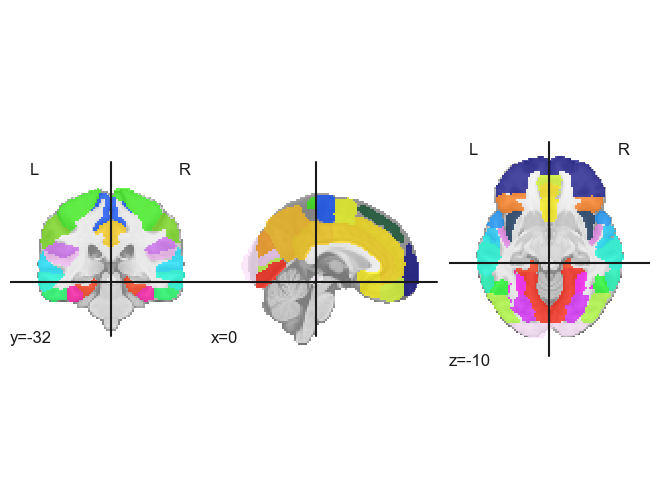

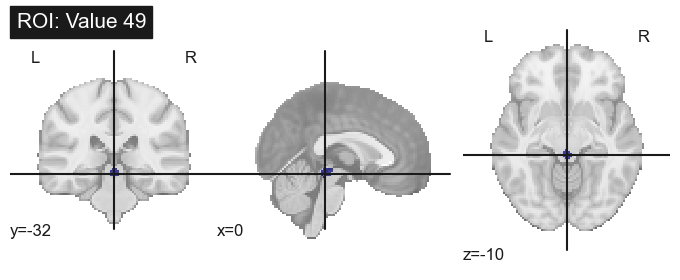

In [13]:
plot_atlas()

Now we plot and save the cortical and subcortical regions.

In [44]:
# plot_save_cortical()
# plot_save_subcortical()

We can also plot unlabelled contrasts.

In [45]:
#plot_unlabelled_contrasts()

### Plot the chronic activations against baseline

IndexError: list index out of range

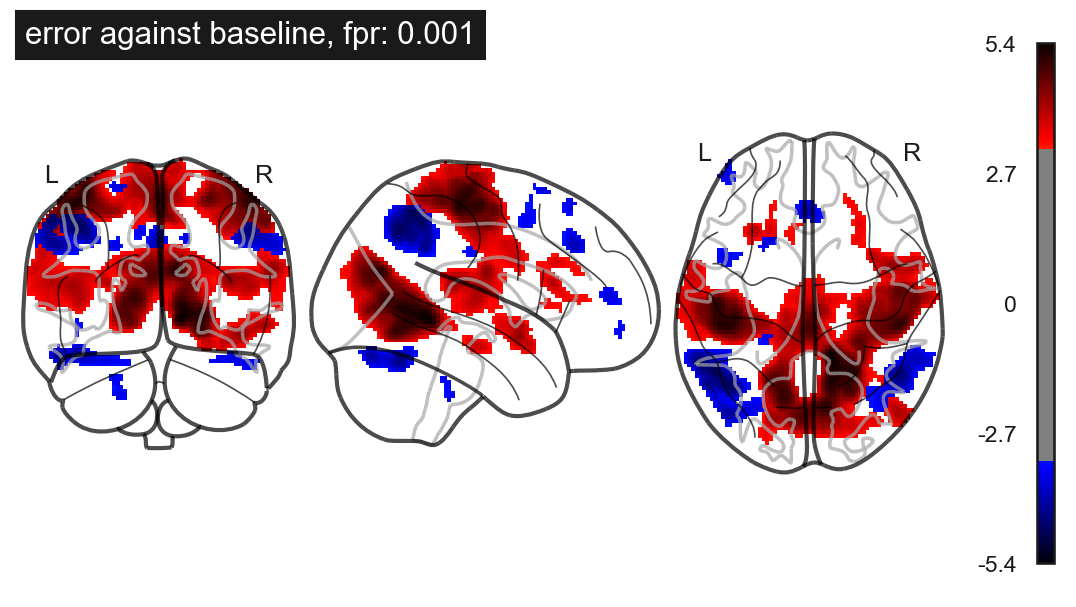

In [14]:
plot_chronic_against_baseline(z_maps_save_path, threshold=2.6,alpha=0.001, compute_regions=True, save=False,plot=True)

### Investigating the distribution of the contrast activations

In [15]:
from scipy import stats

def plot_contrast_distributions(type_of_image):

  #plotting all single_visit_contrasts
  fig, axes = plt.subplots(4,4,figsize=(20,20))
  ax = axes.flatten()
  for i, file in enumerate(os.listdir(f'{z_maps_save_path}/{type_of_image}')):
    z_map = nib.load(f'{z_maps_save_path}/{type_of_image}/{file}')

    data = z_map.get_fdata()
    data = data[data != 0]
    ax[i].hist(data.flatten(),density=True,bins=100)
    mean = np.mean(data)
    #print(mean)
    variance = np.var(data)
    #print(variance)
    sigma = np.sqrt(variance)
    x = np.linspace(min(data), max(data),100)
    ax[i].plot(x,stats.norm.pdf(x,mean,sigma))
  plt.show()

# plot_contrast_distributions('error')
# plot_contrast_distributions('pain')
# plot_contrast_distributions('movement')


So the activations are normally distributed (which they should be, being normally distributed).

## Checking the movement Regressor

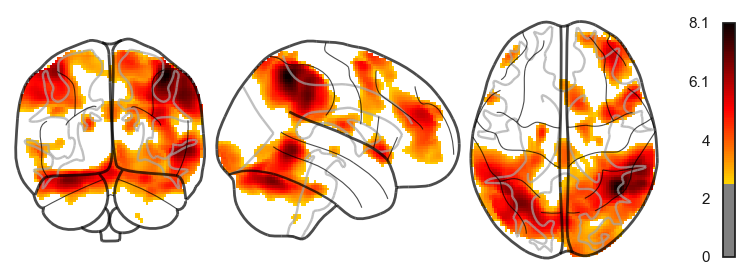

In [16]:
z_map = nib.load("Carl_second_level_z_maps_09_05_2025/movement/movement_against_baseline.nii")
z_map_out, _ = threshold_stats_img(z_map,alpha=0.05,threshold=2.6,
                                    height_control='fdr',cluster_threshold=10,two_sided=False)

plot_glass_brain(z_map_out,plot_abs=False,threshold=2.6,colorbar=True,annotate=False)